<a href="https://colab.research.google.com/github/dattaadithya30-commits/3DOF-Synthesis-Inverse-Kinematics-NN/blob/main/SyntheticInverseKinematicsPredictor_3DOF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

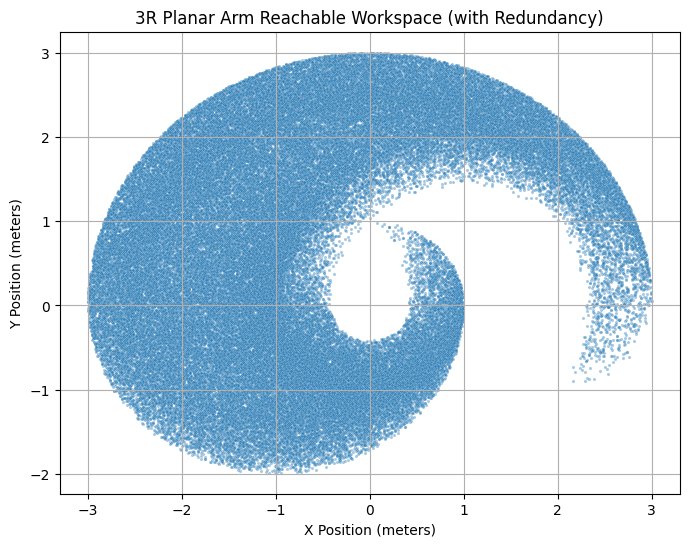

Training Neural Network on 3R Kinematics data...
Training complete!

             EVALUATION METRICS       
Mean Squared Error (MSE):       0.003600 rad^2
Root Mean Squared Error (RMSE):  0.059997 rad
Mean Absolute Error (MAE):      0.032030 rad
----------------------------------------
On average, the NN predicts all 3 joint angles
within 1.84 degrees of accuracy.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


# STEP 1: GENERATE SYNTHETIC DATA (3R Arm)

l1, l2, l3 = 1.0, 1.0, 1.0  # Link lengths
num_samples = 100000  # Increased samples to help Neural Network handle redundancy

# Generate random joint angles (in radians)
# Joint 1: 0 to 180 degrees(semi circle)
theta1 = np.random.uniform(0, np.pi, num_samples)
theta2 = np.random.uniform(0, np.pi, num_samples)
theta3 = np.random.uniform(-np.pi/2, np.pi/2, num_samples)

# 3R Forward Kinematics Equations
x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2) + l3 * np.cos(theta1 + theta2 + theta3)
y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2) + l3 * np.sin(theta1 + theta2 + theta3)
phi = theta1 + theta2 + theta3

df = pd.DataFrame({
    'theta1': theta1,
    'theta2': theta2,
    'theta3': theta3,
    'x': x,
    'y': y,
    'phi': phi
})


# STEP 2: PLOTTING WORKSPACE VISUALIZATION

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x', y='y', s=5, alpha=0.4)
sns.violinplot(data=df, x='x', y='y', color='lightgray')
plt.title("3R Planar Arm Reachable Workspace (with Redundancy)")
plt.xlabel("X Position (meters)")
plt.ylabel("Y Position (meters)")
plt.grid(True)
plt.savefig('3r_workspace.png', dpi=300, bbox_inches='tight')
plt.show()

from sklearn.preprocessing import MinMaxScaler

# STEP 3: PREPARE DATA & TRAIN MODEL
# Inputs: Target Cartesian Coordinates (x, y, phi)
X = df[['x', 'y','phi']]
# Outputs: Required Joint Angles (theta1, theta2, theta3)
Y = df[['theta1', 'theta2', 'theta3']]

# 80% Training, 20% Testing split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Neural Network: 2 hidden layers with 128 neurons each
mlp = MLPRegressor(
    hidden_layer_sizes=(256,128,64),
    activation='tanh',
    max_iter=1500, # Increased max_iter
    random_state=42,
    early_stopping=True, # Enabled early stopping
    validation_fraction=0.1, # Fraction of training data to set aside as validation set
    n_iter_no_change=20, # Number of iterations with no improvement to wait before stopping
    alpha=0.0001 # L2 regularization parameter
)

print("Training Neural Network on 3R Kinematics data...")
mlp.fit(X_train_scaled, Y_train) # Train on scaled data
print("Training complete!")

# STEP 4: ERROR METRIC EVALUATION

predictions = mlp.predict(X_test_scaled)

mse = mean_squared_error(Y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, predictions)

# Convert Mean Absolute Error to physical degrees for interpretation
mae_degrees = np.degrees(mae)

print("\n" + "="*40)
print("             EVALUATION METRICS       ")
print("="*40)
print(f"Mean Squared Error (MSE):       {mse:.6f} rad^2")
print(f"Root Mean Squared Error (RMSE):  {rmse:.6f} rad")
print(f"Mean Absolute Error (MAE):      {mae:.6f} rad")
print("-"*40)
print(f"On average, the NN predicts all 3 joint angles")
print(f"within {mae_degrees:.2f} degrees of accuracy.")
print("="*40)